In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk

nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\dania\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [5]:
df = pd.read_csv("../data/raw_analyst_ratings.csv")
df.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [6]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [5]:
df.columns

Index(['Unnamed: 0', 'headline', 'url', 'publisher', 'date', 'stock'], dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1407328 entries, 0 to 1407327
Data columns (total 6 columns):
 #   Column      Non-Null Count    Dtype                    
---  ------      --------------    -----                    
 0   Unnamed: 0  1407328 non-null  int64                    
 1   headline    1407328 non-null  str                      
 2   url         1407328 non-null  str                      
 3   publisher   1407328 non-null  str                      
 4   date        55987 non-null    datetime64[us, UTC-04:00]
 5   stock       1407328 non-null  str                      
dtypes: datetime64[us, UTC-04:00](1), int64(1), str(4)
memory usage: 64.4 MB


In [7]:

df.isnull().sum()

Unnamed: 0          0
headline            0
url                 0
publisher           0
date          1351341
stock               0
dtype: int64

In [7]:
# basic cleaning
df['date'] = pd.to_datetime(df['date'], errors='coerce')

df = df.dropna(subset=['headline', 'date'])

df['headline'] = df['headline'].astype(str)

df.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [8]:
print("Missing values:\n", df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

df = df.drop_duplicates()

Missing values:
 Unnamed: 0    0
headline      0
url           0
publisher     0
date          0
stock         0
dtype: int64
Duplicates: 0


In [9]:
# Headline Length Analysis
df['headline_length'] = df['headline'].apply(len)
df['headline_length'].describe()

count    55987.000000
mean        80.015254
std         56.126094
min         12.000000
25%         42.000000
50%         63.000000
75%         91.000000
max        512.000000
Name: headline_length, dtype: float64

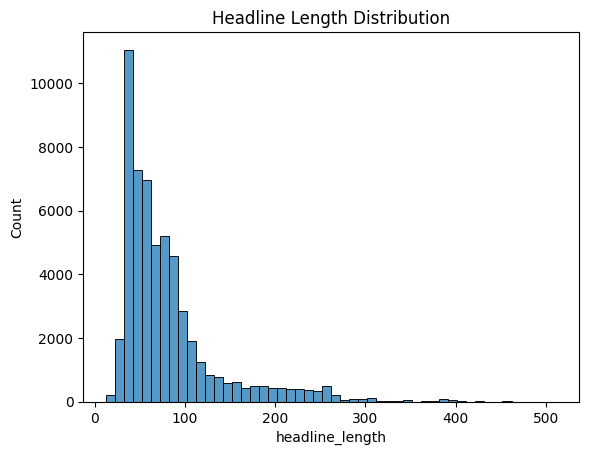

In [10]:
df['headline_length'] = df['headline'].apply(len)

plt.figure()
sns.histplot(df['headline_length'], bins=50)
plt.title("Headline Length Distribution")
plt.show()

In [11]:
#Article per publisher
publisher_counts = df['publisher'].value_counts()

publisher_counts.head(10)

publisher
Benzinga Newsdesk    14750
Lisa Levin           12408
ETF Professor         4362
Paul Quintaro         4212
Benzinga Newsdesk     3177
Benzinga Insights     2332
Vick Meyer            2128
Charles Gross         1790
Hal Lindon            1470
Benzinga_Newsdesk     1239
Name: count, dtype: int64

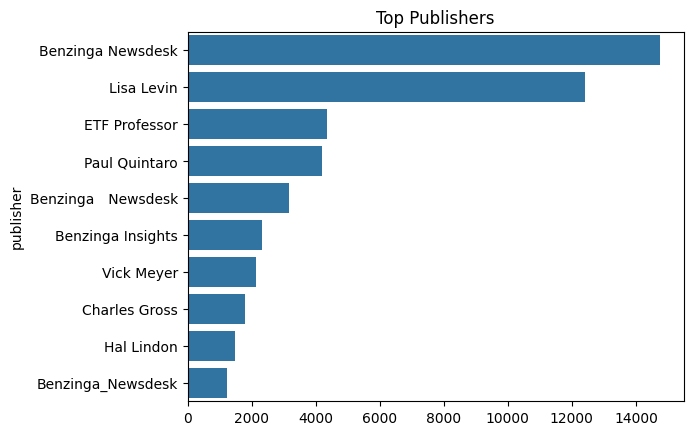

In [12]:
top_publishers = df['publisher'].value_counts().head(10)

plt.figure()
sns.barplot(x=top_publishers.values, y=top_publishers.index)
plt.title("Top Publishers")
plt.show()

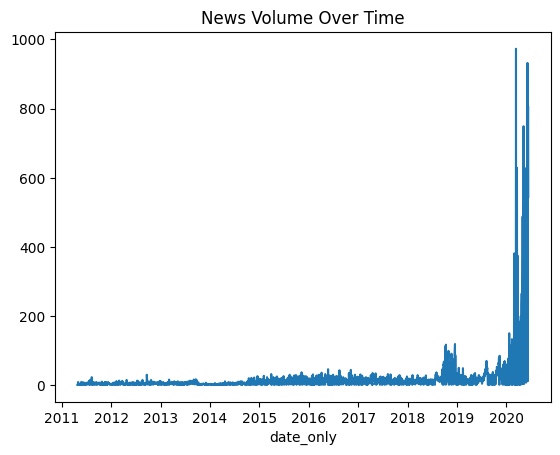

In [13]:
# Article over time 
df['date_only'] = df['date'].dt.date

news_volume = df.groupby('date_only').size()

plt.figure()
news_volume.plot()
plt.title("News Volume Over Time")
plt.show()

In [14]:
# News volum over time
daily_news = df.groupby(df['date'].dt.date).size()

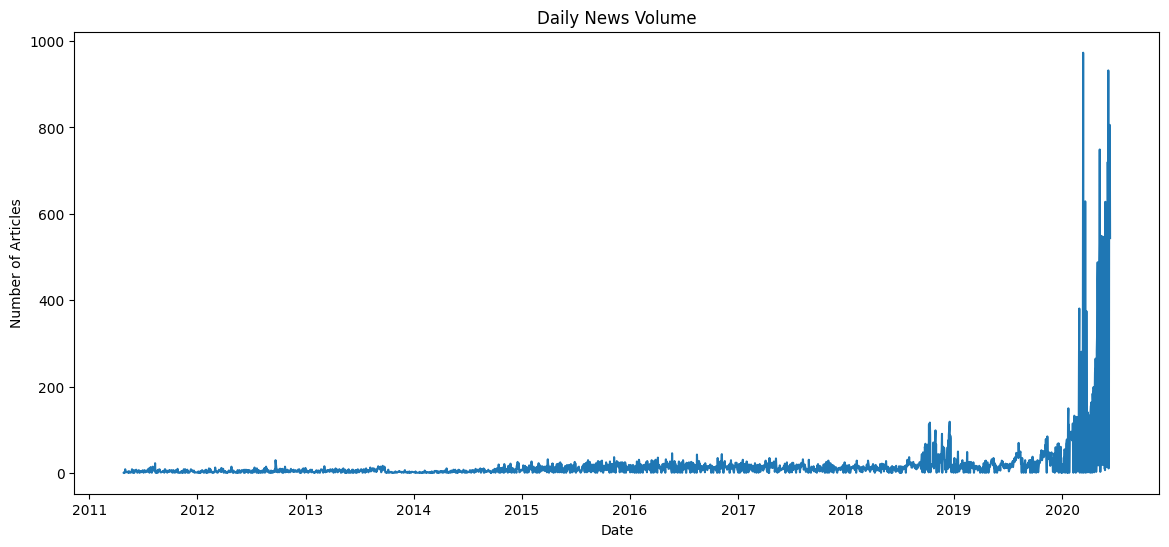

In [15]:
# News publication frequency
plt.figure(figsize=(14,6))

daily_news.plot()

plt.title("Daily News Volume")
plt.xlabel("Date")
plt.ylabel("Number of Articles")

plt.show()

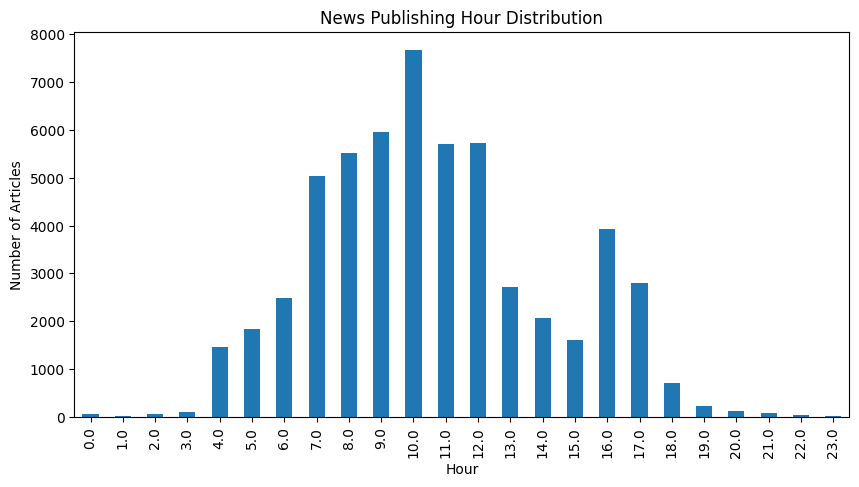

In [21]:
# Publishing Time Analysis
df['hour'] = df['date'].dt.hour
hourly_news = df['hour'].value_counts().sort_index()
plt.figure(figsize=(10,5))

hourly_news.plot(kind='bar')

plt.title("News Publishing Hour Distribution")
plt.xlabel("Hour")
plt.ylabel("Number of Articles")

plt.show()

In [16]:
#TF-IDF Keywords
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=20
)

X = tfidf.fit_transform(df['headline'])

keywords = tfidf.get_feature_names_out()

print(keywords)

['52' 'companies' 'eps' 'estimate' 'higher' 'hit' 'lows' 'maintains'
 'market' 'new' 'price' 'q1' 'sales' 'session' 'shares' 'stocks' 'target'
 'trading' 'week' 'yesterday']


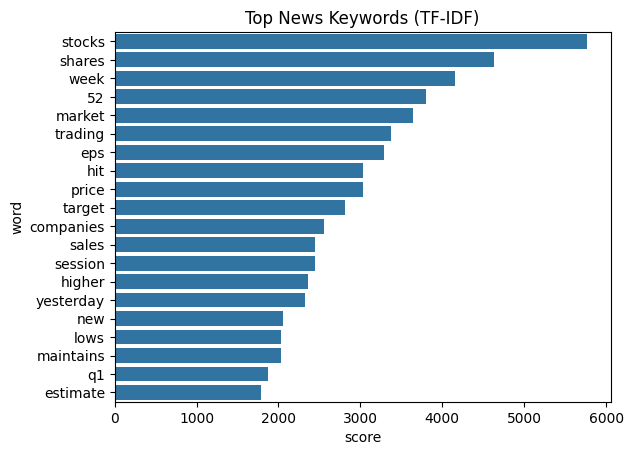

In [ ]:
# nigram alaysis
tfidf = TfidfVectorizer(stop_words='english', max_features=20)
X = tfidf.fit_transform(df['headline'])

keywords = pd.DataFrame({
    'word': tfidf.get_feature_names_out(),
    'score': X.sum(axis=0).A1
}).sort_values(by='score', ascending=False)

plt.figure()
sns.barplot(x='score', y='word', data=keywords)
plt.title("Top News Keywords (TF-IDF)")
plt.show()

In [23]:
# Keyword Frequencies
vectorizer = CountVectorizer(
    stop_words='english',
    max_features=20
)

X_counts = vectorizer.fit_transform(df['headline'])

word_counts = X_counts.sum(axis=0)

words = vectorizer.get_feature_names_out()

word_freq = pd.DataFrame({
    'word': words,
    'count': np.array(word_counts).flatten()
})

word_freq = word_freq.sort_values(
    by='count',
    ascending=False
)

word_freq

,word,count
18,vs,162099
15,stocks,161776
6,est,140604
5,eps,128897
7,market,120558
14,shares,114313
12,reports,108710
17,update,91723
4,earnings,87399
13,sales,79645


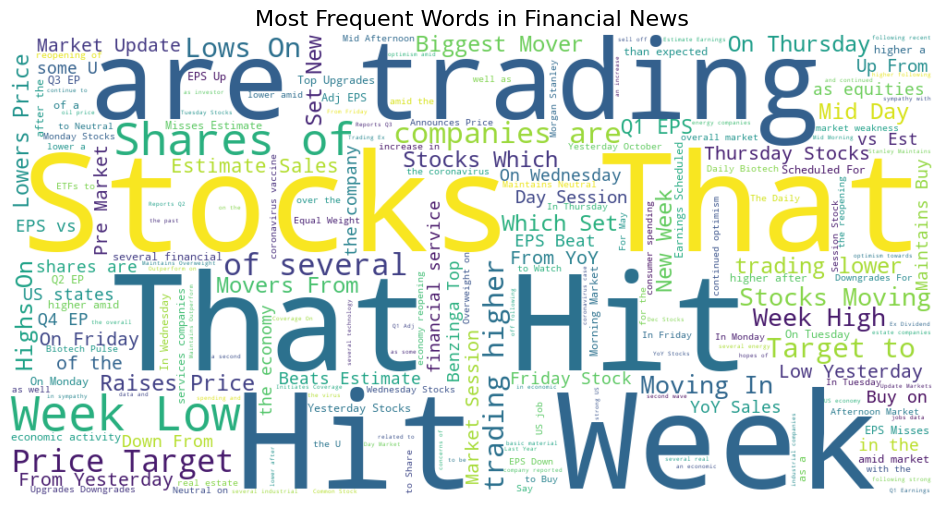

In [17]:
# word cloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(df['headline'].astype(str))

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    stopwords='english'
).generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Most Frequent Words in Financial News", fontsize=16)
plt.show()

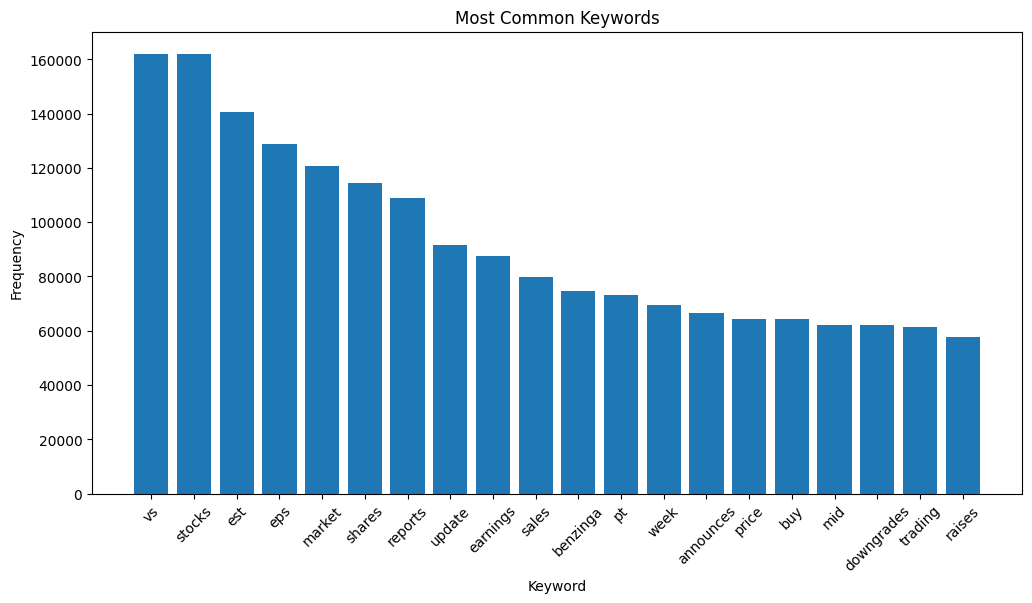

In [24]:
#Most comon keyword
plt.figure(figsize=(12,6))

plt.bar(word_freq['word'], word_freq['count'])

plt.xticks(rotation=45)

plt.title("Most Common Keywords")
plt.xlabel("Keyword")
plt.ylabel("Frequency")

plt.show()

In [ ]:
#Publisher Domain Analysis

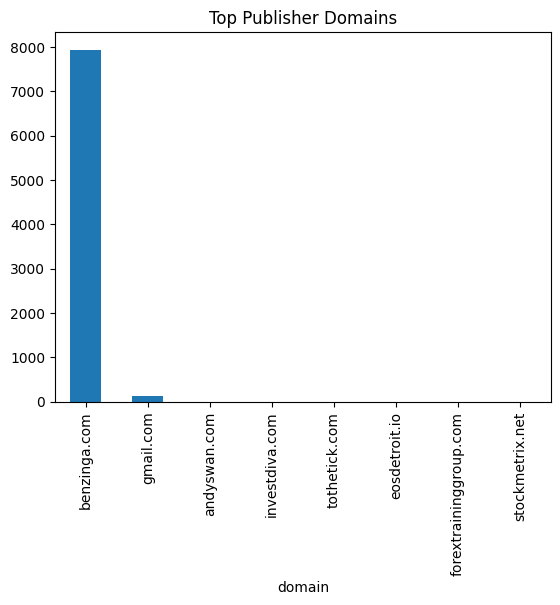

In [26]:
df['publisher'].head()
df['domain'] = df['publisher'].str.extract(r'@(.+)')
domain_counts = df['domain'].value_counts()

domain_counts.head(10)
domain_counts.head(10).plot(kind='bar')

plt.title("Top Publisher Domains")

plt.show()


In [14]:
# Sentiment analysis
sia = SentimentIntensityAnalyzer()

df['sentiment'] = df['headline'].apply(lambda x: sia.polarity_scores(x)['compound'])

df[['headline', 'sentiment']].head()

,headline,sentiment
0,Stocks That Hit 52-Week Highs On Friday,0.000
1,Stocks That Hit 52-Week Highs On Wednesday,0.000
2,71 Biggest Movers From Friday,0.000
3,46 Stocks Moving In Friday's Mid-Day Session,0.000
4,B of A Securities Maintains Neutral on Agilent...,0.296


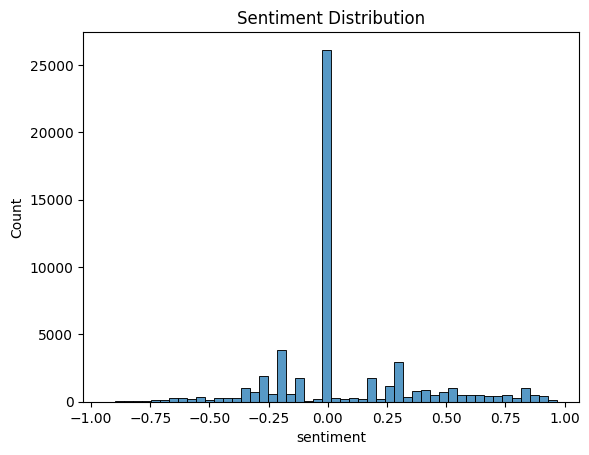

In [15]:
# Sentiment distribution
plt.figure()
sns.histplot(df['sentiment'], bins=50)
plt.title("Sentiment Distribution")
plt.show()

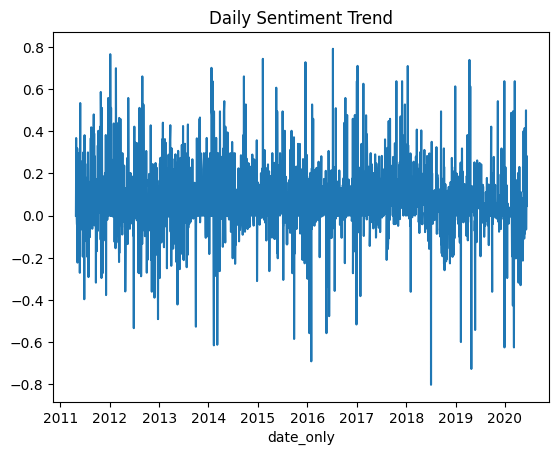

In [16]:
# sentiment over time
daily_sentiment = df.groupby('date_only')['sentiment'].mean()

plt.figure()
daily_sentiment.plot()
plt.title("Daily Sentiment Trend")
plt.show()

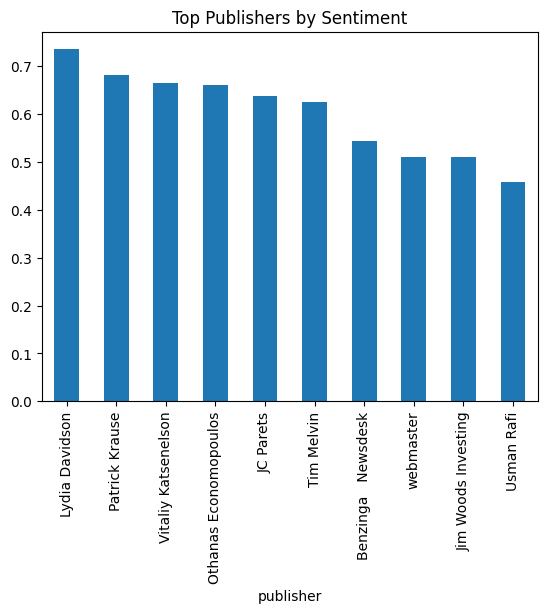

In [17]:
# publisher analysis
publisher_sentiment = df.groupby('publisher')['sentiment'].mean().sort_values(ascending=False).head(10)

plt.figure()
publisher_sentiment.plot(kind='bar')
plt.title("Top Publishers by Sentiment")
plt.show()

In [1]:
# stock tagging
stock_counts = df['stock'].value_counts()

plt.figure()
sns.barplot(x=stock_counts.values, y=stock_counts.index)
plt.title("News per Stock")
plt.show()

NameError: name 'df' is not defined